In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

In [2]:
filepath = './spaceship-titanic/train.csv'
df = pd.read_csv(filepath)
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


Cleaning Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [4]:
categorical_values =df.select_dtypes(include=['object']).columns
numerical_values = df.select_dtypes(exclude=['object']).columns

In [5]:
#replacing null values

for cat_col in categorical_values:
    df[cat_col].fillna(df[cat_col].mode()[0], inplace=True)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9032\1954487954.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cat_col].fillna(df[cat_col].mode()[0], inplace=True)


In [6]:
for num_col in numerical_values:
    df[num_col].fillna(df[num_col].mean(), inplace=True)

In [7]:
len(df)

8693

Analysis

In [8]:
df.describe(include='all')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8693,8693,8693,8693,8693,8693.000000,8693,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693,8693
unique,8693,3,2,6560,3,NaN,2,NaN,NaN,NaN,NaN,NaN,8473,2
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,NaN,False,NaN,NaN,NaN,NaN,NaN,Alraium Disivering,True
freq,1,4803,5656,207,6097,NaN,8494,NaN,NaN,NaN,NaN,NaN,202,4378
mean,NaN,NaN,NaN,NaN,NaN,28.827930,NaN,224.687617,458.077203,173.729169,311.138778,304.854791,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.339054,NaN,659.739364,1594.434978,597.417440,1124.675871,1133.259049,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,37.000000,NaN,78.000000,118.000000,45.000000,89.000000,71.000000,NaN,NaN


In [9]:
#Droping the name column
df.drop(['Name'], axis=1, inplace=True)

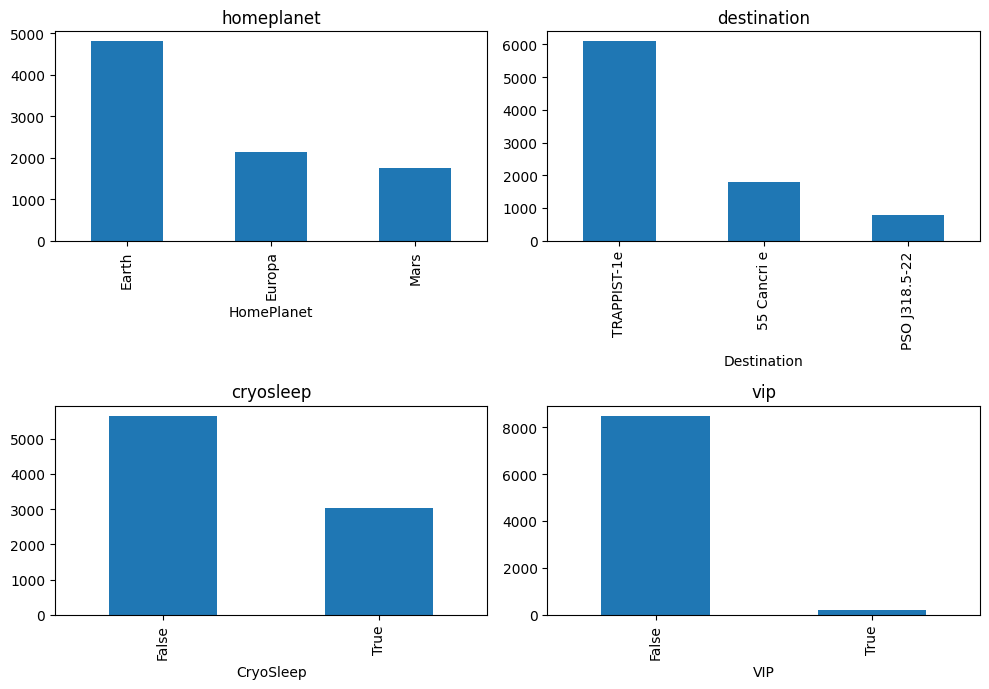

In [10]:
plt.figure(figsize=(10,7))
plt.subplot(2,2,1)
df['HomePlanet'].value_counts().plot(kind='bar',title='homeplanet')
plt.subplot(2,2,2)
df['Destination'].value_counts().plot(kind='bar',title='destination')
plt.subplot(2,2,3)
df['CryoSleep'].value_counts().plot(kind='bar',title='cryosleep')
plt.subplot(2,2,4)
df['VIP'].value_counts().plot(kind='bar',title='vip')
plt.tight_layout()
plt.show()

In [11]:
numerical_variables=list(numerical_values)
if "train"in filepath:
    numerical_variables.remove("Transported")

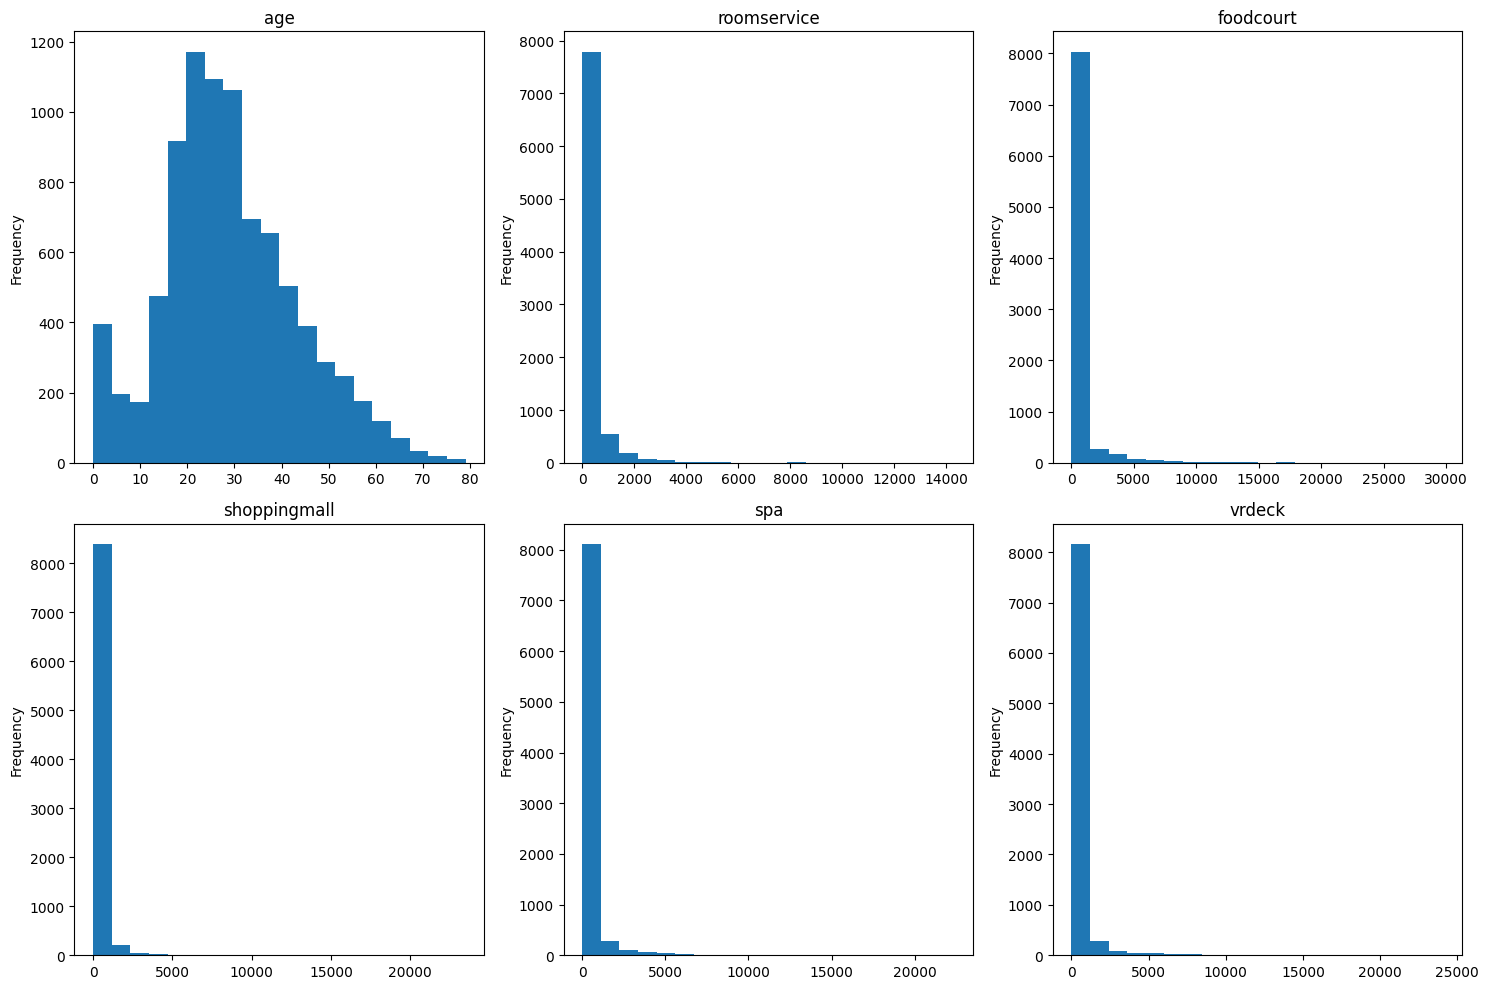

In [12]:
plt.figure(figsize=(15,10))
for i, num_col in enumerate(numerical_variables, 1):
    plt.subplot(2,3,i)
    df[num_col].plot(kind='hist', bins=20)
    plt.title(num_col.lower())
plt.tight_layout()
plt.show()


In [13]:
#building the deck and port features from the 'cabin' feature
df['Deck'] = df['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
df['Port'] = df['Cabin'].apply(lambda s: s[-1] if pd.notnull(s) else 'M')
df['Deck'] = df["Deck"].map({'B':0, 'F':1, 'A':2, 'G':3, 'E':4, 'D':5, 'C':6, 'T':7, 'M':8})
df['Port'] = df["Port"].map({'P':0, 'S':1}).astype(int)
df.drop(['Cabin'], axis=1, inplace=True)
df.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Port
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,0,0
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,1,1
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,2,1
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,2,1
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,1,1


In [14]:
df['HomePlanet']= df['HomePlanet'].map({'Earth':0, 'Europa':1,'Mars':2}).astype(int)
df.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Port
0,0001_01,1,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,0,0
1,0002_01,0,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,1,1
2,0003_01,1,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,2,1
3,0003_02,1,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,2,1
4,0004_01,0,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,1,1


In [15]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Port
0,0001_01,1,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,0,0
1,0002_01,0,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,1,1
2,0003_01,1,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,2,1
3,0003_02,1,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,2,1
4,0004_01,0,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,1,1


In [16]:
unique_destinations = df["Destination"].unique()
df["Destination"] = df["Destination"].map(dict(zip(unique_destinations, list(range(len(unique_destinations)))))).astype(int)

In [17]:
df["Destination"].unique()

array([0, 1, 2])

In [18]:
if 'train' in filepath:
    df.drop(['PassengerId'],axis=1,inplace=True)

In [19]:
unique_cryosleep=df["CryoSleep"].unique()
df["CryoSleep"]=df["CryoSleep"].map(dict(zip(unique_cryosleep, list(range(len(unique_cryosleep)))))).astype(int)

In [20]:
unique_VIP=df["VIP"].unique()
df["VIP"]=df["VIP"].map(dict(zip(unique_VIP, list(range(len(unique_VIP)))))).astype(int)

In [21]:
df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Port
0,1,0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,False,0,0
1,0,0,0,24.0,0,109.0,9.0,25.0,549.0,44.0,True,1,1
2,1,0,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,2,1
3,1,0,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,2,1
4,0,0,0,16.0,0,303.0,70.0,151.0,565.0,2.0,True,1,1


In [24]:
filename =  pathlib.Path(filepath).stem + "_cleaned.csv"
file_dest_path = pathlib.Path("data") / filename
df.to_csv(file_dest_path, index=False)

Model

In [26]:
train=pd.read_csv('./data/train_cleaned.csv')

x=train.drop("Transported", axis=1).values
y=train["Transported"].values

In [27]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=40)
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((6954, 12), (6954,), (1739, 12), (1739,))

In [ ]:
#Fitted different models: Logistic Regression, Random Forest, Gradient Boosting and kneighbors
lg= LogisticRegression()
lg.fit(x_train,y_train)
lg_pred_score=lg.score(x_test,y_test)

c:\Users\Usuario\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
rf_pred_score=rf.score(x_test,y_test)   

In [30]:
gb=GradientBoostingClassifier()
gb.fit(x_train,y_train)
gb_pred_score=gb.score(x_test,y_test)   

In [31]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(x_train,y_train)
svm_pred_score=svm.score(x_test,y_test)

In [32]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
knn_pred_score=knn.score(x_test,y_test)

In [33]:
df=pd.DataFrame(dict(model=['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM', 'KNN'],
                     accuracy=[lg_pred_score, rf_pred_score, gb_pred_score, svm_pred_score, knn_pred_score]))

df

,model,accuracy
0,Logistic Regression,0.780909
1,Random Forest,0.791259
2,Gradient Boosting,0.797585
3,SVM,0.769983
4,KNN,0.759057


(0.0, 1.0)

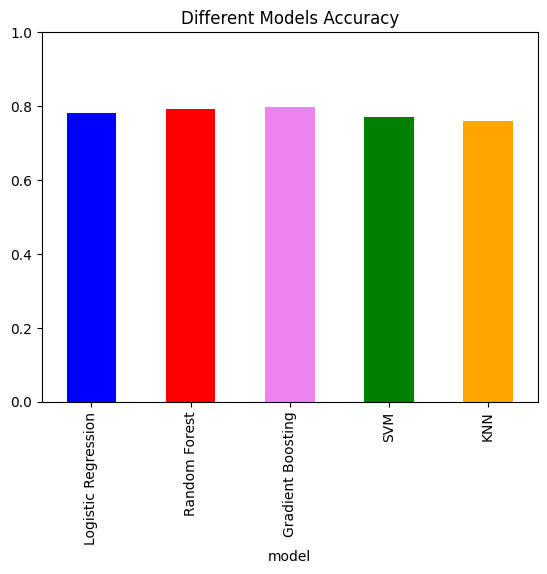

In [34]:
df.plot(kind='bar', x='model',y='accuracy', title='Different Models Accuracy',legend=False,
        color=['blue','red','violet','green','orange'])
plt.ylim(0,1)